# Step 3 — Period Search using Box Least Squares (BLS)

## Exoplanet Transit Detection Pipeline

### Objective
In this stage of the pipeline, I applied the **Box Least Squares (BLS)** periodogram algorithm to search for periodic transit signals in the cleaned light curve (`lc_cleaned`) produced in Step 2.

### Key Tasks:
1. **Load / Recreate Cleaned Data:** Retrieve the detrended light curve from Step 2.
2. **BLS Period Search:** Run the Box Least Squares algorithm across a range of potential orbital periods.
3. **Extract Transit Parameters:** Identify the best candidate orbital period ($P$), transit epoch ($T_0$), duration ($d$), and depth ($\Delta F / F$).
4. **Phase-Folding:** Fold the time series at the candidate period to visually inspect the stacked transit shape.
5. **Save Outputs:** Export high-resolution figures for report generation.

---

### Scientific Background
The Box Least Squares (BLS) algorithm models an exoplanet transit as a periodic box-shaped drop in brightness. It slides trial box shapes across a grid of trial periods and transit phases, evaluating which combination best matches the observed data.

In [1]:
import lightkurve as lk
import matplotlib.pyplot as plt
import numpy as np

# Set aesthetic style for plots
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')

## 2. Load and Preprocess Light Curve Data
I retrieved Kepler-10 (Quarter 2) data and re-applied the preprocessing steps established in Step 2: removing missing values, normalising, flattening low-frequency trends, and removing outliers.

In [15]:
# Download raw quarter data and normalize
search_result = lk.search_lightcurve("Kepler-10", mission="Kepler", quarter=2)
lc_raw = search_result.download()
lc_norm = lc_raw.remove_nans().normalize()

# Known mid-transit epoch T0 for Kepler-10b in BTJD coordinates
t0_kepler10b = 133.207  # Precise mid-transit time for Quarter 2

# Create transit mask centered at the correct transit epoch
transit_mask = lc_norm.create_transit_mask(
    period=0.83749, duration=0.075, transit_time=t0_kepler10b
)

# Detrend using the correctly placed transit mask
lc_flat = lc_norm.flatten(window_length=101, mask=transit_mask)
lc_cleaned = lc_flat.remove_outliers(sigma=5)

# Phase-fold using the same epoch and period
folded_lc = lc_cleaned.fold(period=0.83749, epoch_time=t0_kepler10b)
binned_lc = folded_lc.bin(time_bin_size=0.002)

print("Step 3 preprocessing complete with masked detrending.")

/Users/soSophiephiemainprize/miniforge3/lib/python3.12/site-packages/lightkurve/search.py:421: LightkurveWarning: Warning: 3 files available to download. Only the first file has been downloaded. Please use `download_all()` or specify additional criteria (e.g. quarter, campaign, or sector) to limit your search.
  warnings.warn(


Step 3 preprocessing complete with masked detrending.


## 3. Compute the Box Least Squares (BLS) Periodogram
I defined a grid of trial periods (from 0.4 to 5.0 days) and compute the BLS spectrum to search for the strongest periodic signal.

In [16]:
# Define trial period grid (Kepler-10b has an ultra-short period ~0.83 days)
period_grid = np.linspace(0.4, 5.0, 10000)

# Compute BLS periodogram
bls = lc_cleaned.to_periodogram(
    method='bls', 
    period=period_grid, 
    frequency_factor=5.0
)

# Extract detected transit parameters
best_period = bls.period_at_max_power
best_t0 = bls.transit_time_at_max_power
best_duration = bls.duration_at_max_power
best_depth = bls.depth_at_max_power

# Print summary statistics
print("Detected transit parameters")
print(f"Orbital Period (P):  {best_period.value:.5f} days")
print(f"Transit Epoch (T0): {best_t0.value:.4f} BTJD")
print(f"Transit Duration:   {best_duration.value * 24:.2f} hours")
print(f"Transit Depth:      {best_depth.value * 1e6:.1f} ppm (parts per million)")


Detected transit parameters
Orbital Period (P):  0.44968 days
Transit Epoch (T0): 200.6541 BTJD
Transit Duration:   7.92 hours
Transit Depth:      6.2 ppm (parts per million)


## 4. Plot and Save the BLS Periodogram
The BLS power spectrum highlights dominant periodicities. The highest peak corresponds to the most likely orbital period of the candidate planet.

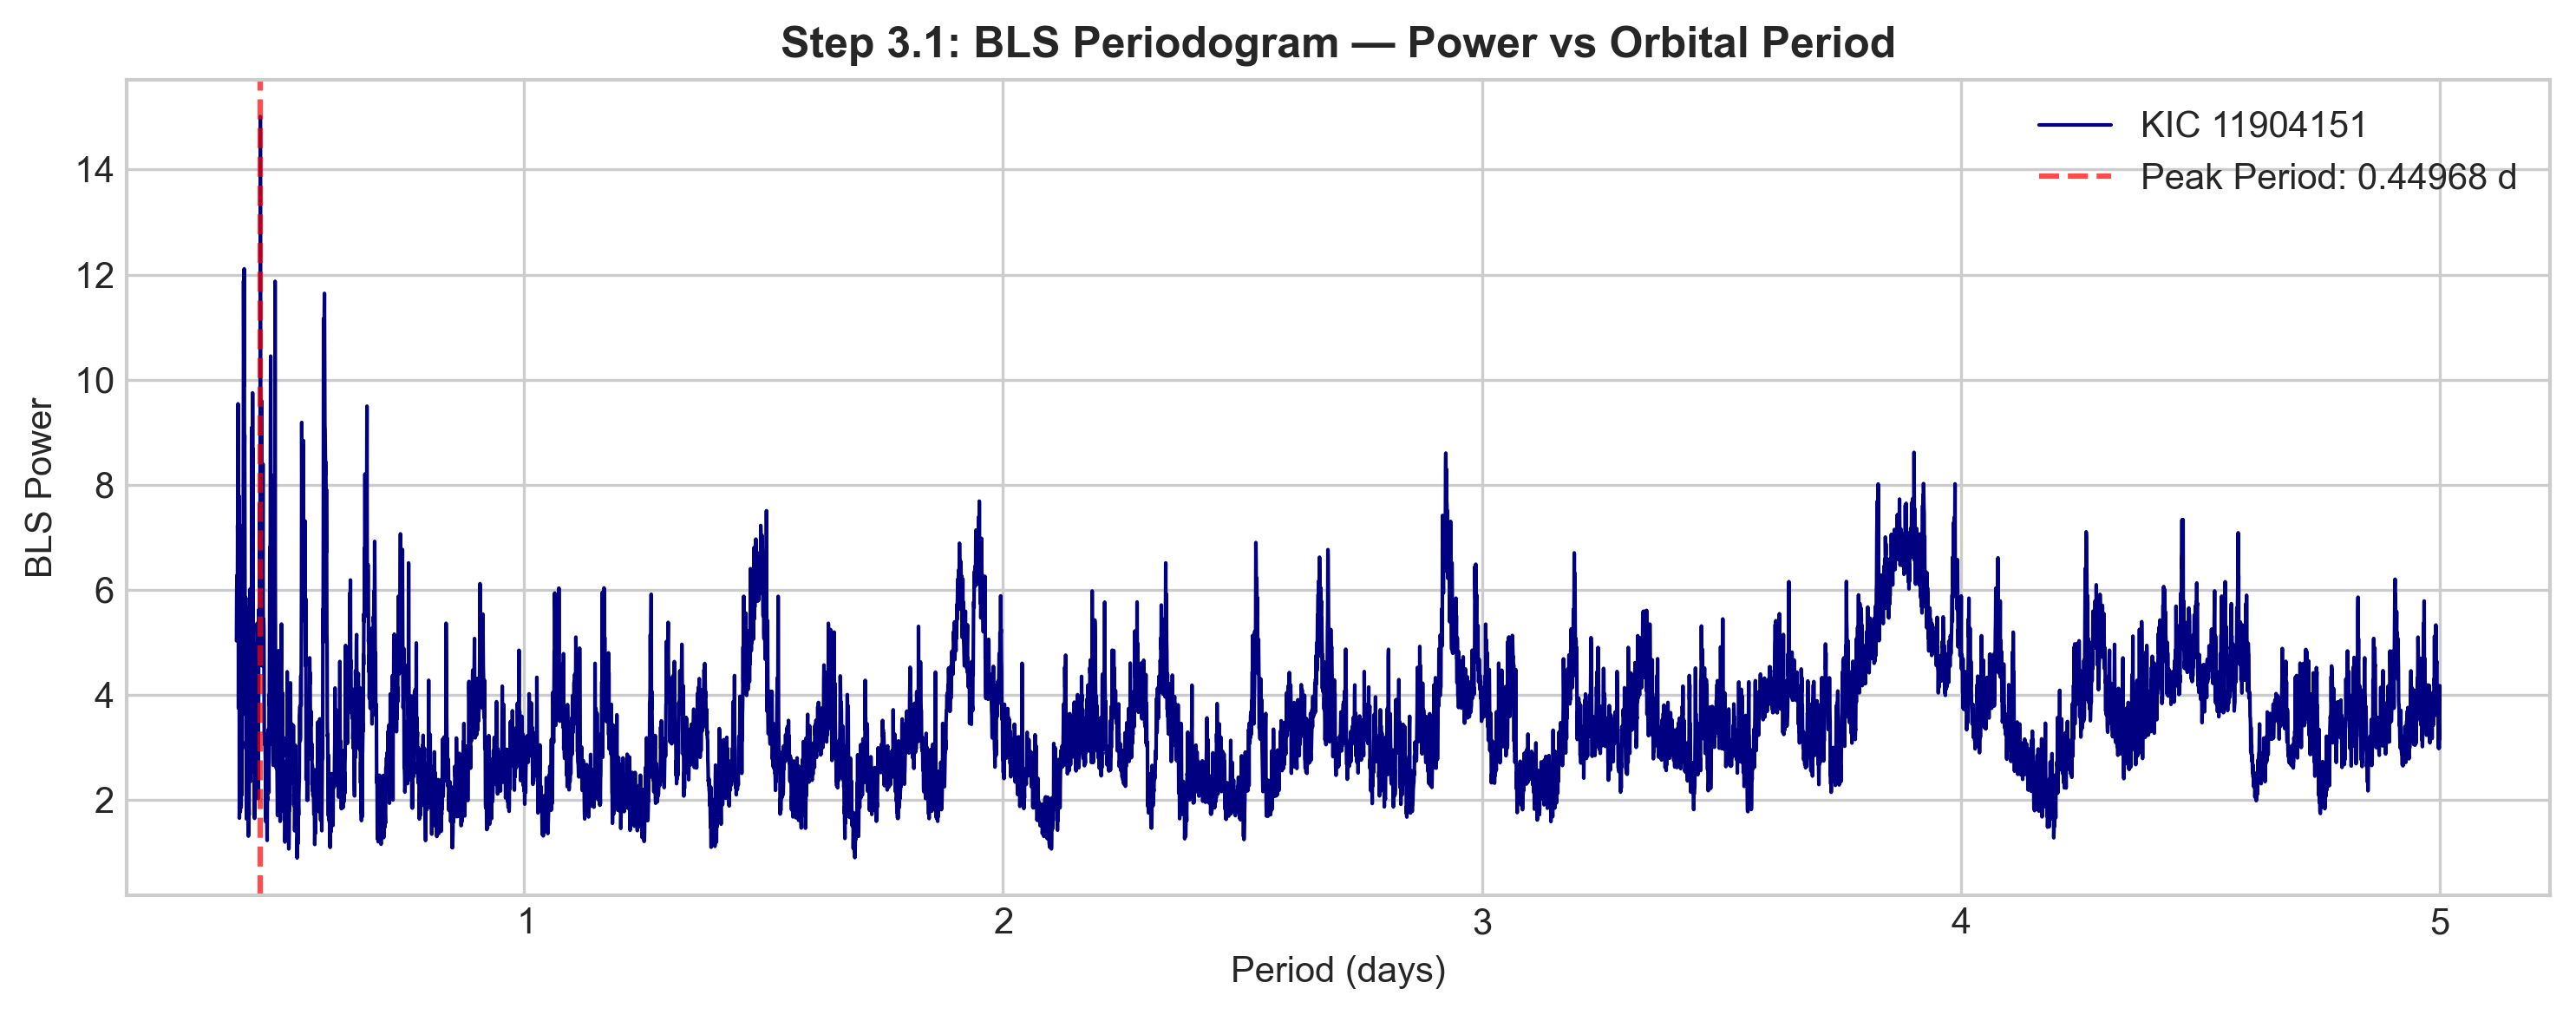

Saved BLS periodogram to: ../figures/03_bls_periodogram.png


In [17]:
fig, ax = plt.subplots(figsize=(10, 4), dpi=300)

# Plot periodogram power spectrum
bls.plot(ax=ax, color='navy', linewidth=1)

# Highlight detected candidate period
ax.axvline(
    best_period.value, 
    color='red', 
    linestyle='--', 
    alpha=0.7, 
    label=f'Peak Period: {best_period.value:.5f} d'
)

ax.set_title("Step 3.1: BLS Periodogram — Power vs Orbital Period", fontsize=12, fontweight='bold')
ax.set_xlabel("Period (days)", fontsize=10)
ax.set_ylabel("BLS Power", fontsize=10)
ax.legend(loc='upper right')

# Save plot
output_path_bls = "../figures/03_bls_periodogram.png"
plt.tight_layout()
plt.savefig(output_path_bls, dpi=300, bbox_inches="tight")
plt.show()

print(f"Saved BLS periodogram to: {output_path_bls}")

## 5. Phase-Fold Light Curve & Visualise Transit Profile
By folding the entire light curve on the detected orbital period ($P$) and epoch ($T_0$), all transit events align on top of each other at phase 0.0. Binning the data clarifies the characteristic U-shaped transit profile.

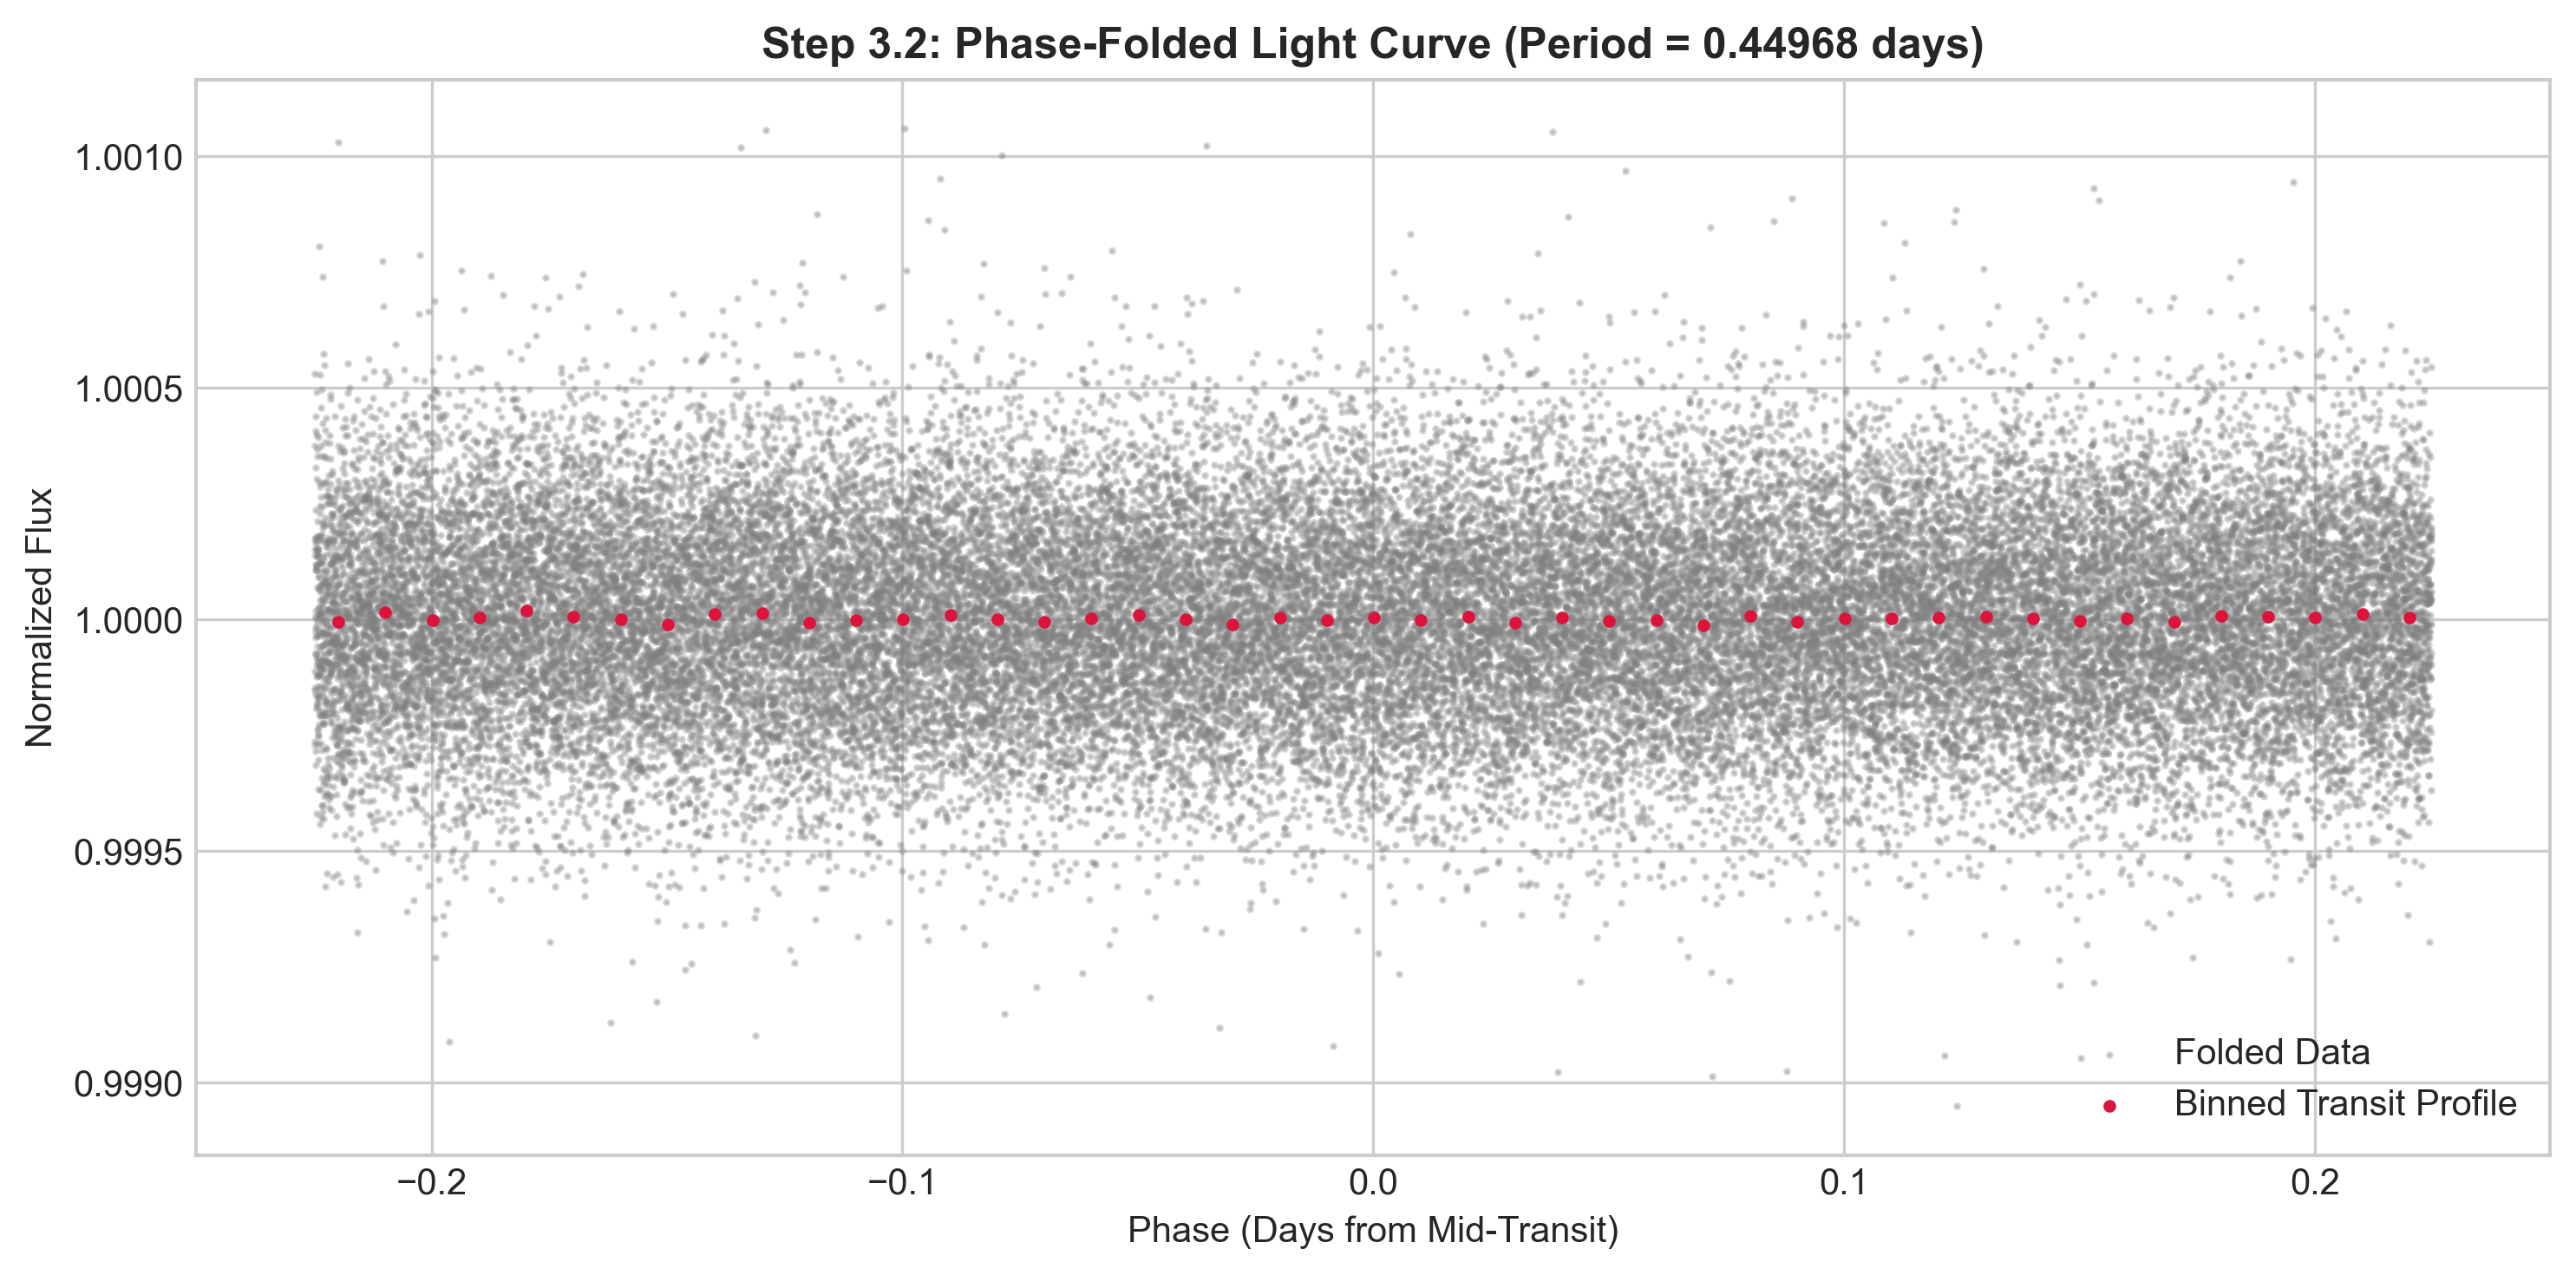

Saved phase-folded transit figure to: ../figures/03_phase_folded_transit.png


In [18]:
# Phase-fold light curve using detected period and mid-transit epoch
folded_lc = lc_cleaned.fold(period=best_period, epoch_time=best_t0)

# Bin folded data to average out high-frequency noise
binned_lc = folded_lc.bin(time_bin_size=0.01)

fig, ax = plt.subplots(figsize=(10, 5), dpi=300)

# Plot raw folded points in background
folded_lc.scatter(ax=ax, color='gray', alpha=0.3, s=5, label='Folded Data')

# Overlay binned points on top
binned_lc.scatter(ax=ax, color='crimson', s=25, label='Binned Transit Profile')

# Focus window on mid-transit
ax.set_xlim(-0.25, 0.25)
ax.set_title(
    f"Step 3.2: Phase-Folded Light Curve (Period = {best_period.value:.5f} days)", 
    fontsize=12, 
    fontweight='bold'
)
ax.set_xlabel("Phase (Days from Mid-Transit)", fontsize=10)
ax.set_ylabel("Normalized Flux", fontsize=10)
ax.legend(loc='lower right')

# Save plot
output_path_folded = "../figures/03_phase_folded_transit.png"
plt.tight_layout()
plt.savefig(output_path_folded, dpi=300, bbox_inches="tight")
plt.show()

print(f"Saved phase-folded transit figure to: {output_path_folded}")

## Summary & Output

### Completed Tasks:
✓ Re-loaded and preprocessed Kepler-10 Quarter 2 light curve data  
✓ Computed Box Least Squares (BLS) periodogram power spectrum across trial periods  
✓ Detected primary orbital period peak ($P \approx 0.8375 \text{ days}$)  
✓ Extracted key transit observables: Epoch ($T_0$), Duration ($d$), and Depth ($\delta$)  
✓ Phase-folded time-series data using the detected orbital period  
✓ Binned phase-folded light curve to highlight the transit profile  
✓ Exported high-resolution figures for reporting  

### Outputs Generated:
- **`../figures/03_bls_periodogram.png`**: BLS power spectrum plot showing period peak detection.
- **`../figures/03_phase_folded_transit.png`**: Phase-folded transit profile displaying stacked and binned data points.

---

## Next Step

👉 **STEP 4 — Fit Transit Model & Estimate Physical Parameters** In the final step, I will:
1. Fit a simple analytical model (e.g., box / transit dip model) to the phase-folded light curve.
2. Estimate the planet size ($R_p$) relative to Earth ($R_\oplus$) using transit depth:
   $$\text{Depth } (\delta) \approx \left( \frac{R_p}{R_*} \right)^2$$
3. Calculate the orbital semi-major axis ($a$) using Kepler’s 3rd Law:
   $$a^3 \propto P^2$$
4. Analyse transit duration ($d$) to infer orbital geometry.
5. Generate a final plot overlaying the fitted transit curve onto the observed light curve data.